# Baseline A — Locally Covariance-Informed Perturbation (Cyrils Reference Mechanism)

**Central, subject-level DP for neuroimaging pipeline outputs — faithful reference implementation.**

The per-patch noise mechanism here is a **faithful port of the prototype's reference code** (the bivariate `bivariate_dp_optimized`), generalized from `p=2` features to the `p=8` voxels of a spatial patch. On top of that within-patch mechanism sits the imaging spec's patch tiling:

- `2×2×2` patches, **0% overlap** (imaging spec §4/§10)
- noise covariance = the reference's `diag(sf)·Cov(subjects)·diag(sf)` with `sf = (2·loo_scale)/√diag(Cov(subjects))`, `loo_scale = std(LOO)/ε`
- Cholesky sampling; reject until `|z_j| ≥ S_j` for **every** voxel
- on failure, the reference's **independent-noise fallback** (redraw each voxel until it clears `S_j`)

Working example pipeline: the **voxelwise mean image** `y = mean_i x_i`, on real spatially-normalized structural data (OASIS VBM gray-matter maps, MNI space).

### What this notebook is and is not

The project's three questions are kept separate:

- **(A)** Does the code reproduce the prototype's algorithm? — *this notebook's job.*
- **(B)** Does it empirically protect the output? — later (attacks / utility).
- **(C)** Does it satisfy a formal (ε, δ)-DP guarantee? — **not claimed here.** The rejection + fallback rule is an operational recipe, not a DP proof.

Nothing here is a privacy guarantee. We *measure* behavior — in particular, how often the mechanism falls back to independent noise.

## A useful correctness oracle (mean pipeline only)

For the mean pipeline the LOO difference has a closed form. With `y = (1/N)Σⱼ xⱼ` and `y₋ᵢ = (1/(N-1))Σⱼ≠ᵢ xⱼ`:

$$ d_i = y_{-i} - y = \frac{y - x_i}{N-1}. $$

Two consequences we exploit as unit tests:

1. **Sensitivity oracle:** `S(v) = maxᵢ |y(v) - xᵢ(v)| / (N-1)` — driven entirely by the single most extreme subject at each voxel.
2. **Covariance oracle:** the LOO-based patch covariance is, up to a scalar, just the *spatial covariance of the subjects* inside the patch:
$$ \Sigma_P = \operatorname{Cov}_i(d_{i,P}) = \frac{1}{(N-1)^2}\operatorname{Cov}_i(x_{i,P}). $$

The code path that reruns the pipeline `N` times must reproduce these to floating-point precision. We assert both below before trusting anything on real data.

> Note this also foreshadows a tension flagged in the spec (§15): `S` here is a max over subjects — an *empirical LOO / local sensitivity*, not a global sensitivity. We use it as specified and measure the consequences.

In [1]:
# ============================================================
# Configuration & imports
# ============================================================
import os, json, time, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import norm

warnings.filterwarnings("ignore", category=RuntimeWarning)
RNG = np.random.default_rng(20240601)

# ---- Data source -------------------------------------------------
# Real data (default): OASIS VBM gray-matter maps via nilearn (already in MNI space).
# Set USE_SYNTHETIC = True (or export BASELINE_A_SYNTHETIC=1) to run fully offline.
USE_SYNTHETIC = os.environ.get("BASELINE_A_SYNTHETIC", "false").lower() in ("1", "true", "yes")

# ---- Core Baseline A parameters (imaging spec: patch geometry) ----
PATCH   = (2, 2, 2)     # 2x2x2 patches
STRIDE  = (2, 2, 2)     # 0% overlap

# ---- prototype reference-mechanism parameters (bivariate_dp_optimized) ----
# The per-patch noise mechanism is a faithful port of the prototype's reference code:
#   noise_cov = diag(sf) @ Cov(subjects) @ diag(sf),  sf = (2*loo_scale)/sqrt(diag(Cov(subjects)))
#   loo_scale = std(LOO)/EPSILON ; reject until |z_j| >= S_j for all j ;
#   on failure -> INDEPENDENT per-dimension noise redrawn until |z_j| >= S_j (guarantees the bound).
EPSILON   = 1.0         # reference privacy knob (scales loo_scale; larger -> smaller noise)
MAX_DRAWS = 10000       # correlated rejection attempts before the independent fallback (reference value)
REG_FLOOR = 1e-10       # regularize if min eigenvalue <= this
REG_ADD   = 1e-8        # ridge added to the diagonal when regularizing (reference value)
INDEP_CAP = 100000      # safety cap on the reference's unbounded fallback while-loop (logged if hit)

# ---- Experiment knobs (tractability only; documented in the run log) ----
MAX_SUBJECTS  = 30      # LOO reruns the pipeline N times -> keep N modest for the reference run
CROP_TO_BRAIN = True    # crop volume to the brain bounding box (fewer empty patches; logged)

OUTDIR = "outputs"; os.makedirs(OUTDIR, exist_ok=True)
LOG = {}  # master run-log; every stage appends to this

print("USE_SYNTHETIC =", USE_SYNTHETIC)
print(f"PATCH {PATCH} STRIDE {STRIDE} | N<= {MAX_SUBJECTS} | EPSILON {EPSILON} | MAX_DRAWS {MAX_DRAWS}")

USE_SYNTHETIC = False
PATCH (2, 2, 2) STRIDE (2, 2, 2) | N<= 30 | EPSILON 1.0 | MAX_DRAWS 10000


## 1. Load the protected dataset

We load `N` spatially-normalized subject volumes into a single array `X` of shape `(N, X, Y, Z)`, plus the affine and a brain mask. In the platform setting these would live inside the trusted environment; here we stand in with public OASIS gray-matter maps (real data, MNI-aligned, so a voxelwise mean is meaningful).

Everything downstream treats `X` as an opaque stack of aligned images, so swapping in fMRI or another modality only changes this cell.

In [2]:
def load_real_oasis(n_subjects):
    from nilearn import datasets
    oasis = datasets.fetch_oasis_vbm(n_subjects=n_subjects)
    paths = list(oasis.gray_matter_maps)
    imgs = [nib.load(p) for p in paths]
    affine = imgs[0].affine
    X = np.stack([im.get_fdata(dtype=np.float32) for im in imgs]).astype(np.float32)
    return X, affine, {"modality": "T1/VBM gray-matter (OASIS)", "source": "nilearn.fetch_oasis_vbm"}

def make_synthetic(n_subjects, shape=(24, 24, 24), seed=0):
    rng = np.random.default_rng(seed)
    grids = np.meshgrid(*[np.linspace(-1, 1, s) for s in shape], indexing="ij")
    r2 = sum(g**2 for g in grids)
    base = np.exp(-r2 / 0.5).astype(np.float32)           # smooth "brain"
    brain = base > 0.2
    # Zero the background so the mask is genuine tissue (nonzero sensitivity throughout),
    # matching how a real MNI-space brain mask behaves. Subject variation only inside the brain.
    base = (base * brain).astype(np.float32)
    X = np.stack([(base + 0.15 * rng.standard_normal(shape).astype(np.float32) * brain) * brain
                  for _ in range(n_subjects)])
    affine = np.eye(4, dtype=np.float32)
    return X, affine, {"modality": "SYNTHETIC aligned volumes", "source": "make_synthetic"}

t0 = time.time()
if USE_SYNTHETIC:
    X, AFFINE, dmeta = make_synthetic(MAX_SUBJECTS)
else:
    X, AFFINE, dmeta = load_real_oasis(MAX_SUBJECTS)
load_time = time.time() - t0

N = X.shape[0]
# brain mask: finite everywhere and not identically zero across subjects
finite_all = np.isfinite(X).all(0)
nonzero_any = (X != 0).any(0)
BRAIN = finite_all & nonzero_any

# optional crop to brain bounding box (logged) -- keeps the affine correct
if CROP_TO_BRAIN and BRAIN.any():
    idx = np.array(np.where(BRAIN))
    lo = idx.min(1); hi = idx.max(1) + 1
    sl = tuple(slice(int(l), int(h)) for l, h in zip(lo, hi))
    X = X[(slice(None),) + sl]
    BRAIN = BRAIN[sl]
    AFFINE = AFFINE.copy()
    AFFINE[:3, 3] = AFFINE[:3, 3] + AFFINE[:3, :3] @ lo.astype(float)
    crop = {"lo": lo.tolist(), "hi": hi.tolist()}
else:
    crop = None

SHAPE = X.shape[1:]
LOG["dataset"] = {**dmeta, "N": int(N), "output_shape": list(SHAPE),
                  "n_brain_voxels": int(BRAIN.sum()), "crop": crop,
                  "load_time_s": round(load_time, 2)}
print(f"Loaded N={N} subjects | volume {SHAPE} | brain voxels {int(BRAIN.sum())} | {load_time:.1f}s")
print("modality:", dmeta["modality"])

[fetch_oasis_vbm] Dataset found in /users/lukasschuler/nilearn_data/oasis1

Loaded N=30 subjects | volume (90, 109, 90) | brain voxels 867102 | 2.4s
modality: T1/VBM gray-matter (OASIS)


## 2. The researcher pipeline `f(D)`

The platform runs a researcher-provided pipeline on the protected data. Here the working example is the **voxelwise mean image**. It is deliberately isolated behind a single function so a container / NIfTI-based pipeline can be substituted without touching the mechanism.

The only assumption the mechanism makes is: `pipeline(stack) -> image` of fixed shape.

In [3]:
def pipeline(stack):
    # Working example: voxelwise mean. Stands in for an arbitrary researcher pipeline f(D).
    return stack.mean(axis=0)

y = pipeline(X)
print("pipeline output shape:", y.shape, "| dtype:", y.dtype)

pipeline output shape: (90, 109, 90) | dtype: float32


## 3. Leave-one-out perturbation images & the sensitivity brain

Run `f` once on the full dataset, then once per subject with that subject removed (remove-one adjacency). For each subject:

$$ d_i = f(D \setminus \{x_i\}) - f(D). $$

We compute this by **actually rerunning the pipeline** `N` times (the general, pipeline-agnostic path), and then **assert** it against the mean-pipeline closed form `d_i = (y - x_i)/(N-1)`. If that assertion passes, the LOO machinery is trustworthy for any pipeline.

In [4]:
t0 = time.time()
D = np.empty_like(X)                       # (N, X, Y, Z) LOO perturbation images
for i in range(N):
    D[i] = pipeline(np.delete(X, i, axis=0)) - y
loo_time = time.time() - t0

# --- ORACLE 1: closed-form LOO for the mean pipeline ---
D_closed = (y - X) / (N - 1)
oracle_err = float(np.abs(D - D_closed).max())
print(f"LOO reruns: {N} in {loo_time:.1f}s | closed-form max abs error = {oracle_err:.2e}")
assert oracle_err < 1e-5, "LOO does not match the mean-pipeline closed form!"
LOG["loo"] = {"loo_reruns": int(N), "loo_time_s": round(loo_time, 2),
              "closed_form_max_abs_err": oracle_err}
print("ORACLE 1 passed: LOO machinery reproduces the closed form.")

LOO reruns: 30 in 5.8s | closed-form max abs error = 2.44e-07
ORACLE 1 passed: LOO machinery reproduces the closed form.


## 4. Voxelwise empirical sensitivity `S(v)` and the analysis mask

$$ S(v) = \max_i |d_i(v)|. $$

This is the **empirical LOO / local** sensitivity — a max over subjects, *not* a certified global sensitivity (a point we return to in the findings). Voxels where the output is undefined / absent are excluded to form the analysis mask.

In [5]:
S = np.abs(D).max(axis=0)                        # sensitivity brain
ANALYSIS = BRAIN & np.isfinite(S)                # valid voxels
S_filled = np.where(ANALYSIS, S, 0.0)            # 0 outside mask -> rule trivially satisfied there

sb = S[ANALYSIS]
LOG["sensitivity"] = {
    "min": float(sb.min()), "max": float(sb.max()),
    "mean": float(sb.mean()), "median": float(np.median(sb)),
    "q10": float(np.quantile(sb, .1)), "q90": float(np.quantile(sb, .9)),
    "n_zero_sensitivity": int((sb == 0).sum()), "mask_size": int(ANALYSIS.sum()),
}
print("Sensitivity over analysis mask:",
      {k: round(v, 6) if isinstance(v, float) else v for k, v in LOG["sensitivity"].items()})

Sensitivity over analysis mask: {'min': 3e-06, 'max': 0.042962, 'mean': 0.003291, 'median': 0.001061, 'q10': 9.2e-05, 'q90': 0.011886, 'n_zero_sensitivity': 0, 'mask_size': 867102}


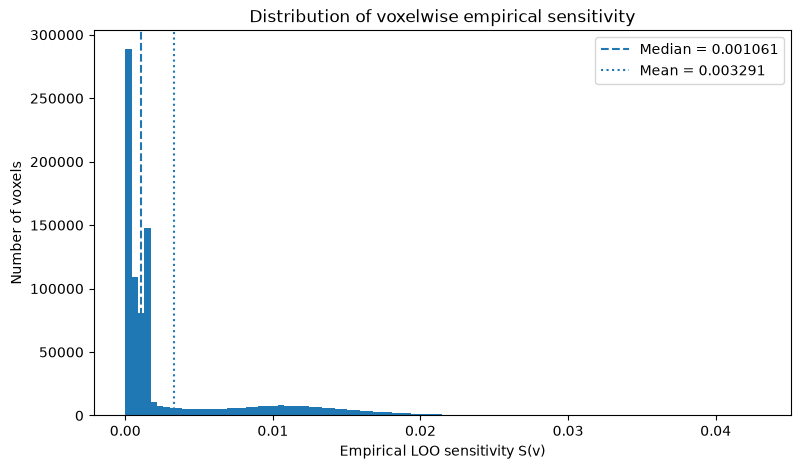

In [6]:
# Distribution of empirical voxelwise sensitivity values
sens_values = S[ANALYSIS]

plt.figure(figsize=(9, 5))

plt.hist(
    sens_values,
    bins=100,
)

plt.axvline(
    np.median(sens_values),
    linestyle="--",
    label=f"Median = {np.median(sens_values):.4g}",
)

plt.axvline(
    np.mean(sens_values),
    linestyle=":",
    label=f"Mean = {np.mean(sens_values):.4g}",
)

plt.xlabel("Empirical LOO sensitivity S(v)")
plt.ylabel("Number of voxels")
plt.title(
    "Distribution of voxelwise empirical sensitivity"
)
plt.legend()

plt.show()

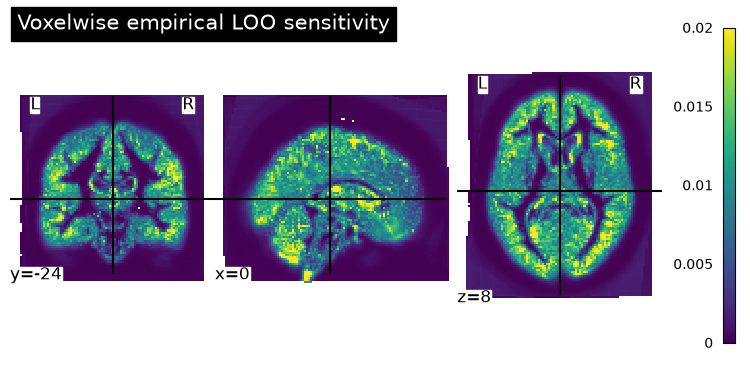

In [7]:
from nilearn import plotting
import nibabel as nib

# Keep only analysis voxels
sens_plot = np.where(
    ANALYSIS,
    S,
    0.0,
).astype(np.float32)

sens_nii = nib.Nifti1Image(
    sens_plot,
    AFFINE,
)

# Robust upper limit so a few extreme voxels
# do not dominate the color scale
vmax = np.percentile(
    S[ANALYSIS],
    99,
)

plotting.plot_stat_map(
    sens_nii,
    display_mode="ortho",
    cmap="viridis",
    threshold=0,
    vmax=vmax,
    colorbar=True,
    title="Voxelwise empirical LOO sensitivity",
)

plotting.show()

## 5. Patch geometry — `2×2×2`, 0% overlap

We tile the volume with non-overlapping `2×2×2` blocks. Voxels in a high-edge remainder (when a dimension is odd) are left unperturbed and counted. With 0% overlap every covered voxel receives **exactly one** patch contribution, so no averaging is needed yet (that is Baseline C).

Voxel ordering inside a patch is fixed by a single `reshape` and reused everywhere (covariance, sensitivity vector, noise placement) so indices never get scrambled.

In [8]:
def enumerate_patches(shape, patch, stride):
    (nx, ny, nz), (px, py, pz), (sx, sy, sz) = shape, patch, stride
    corners = [(x, yy, z)
               for x in range(0, nx - px + 1, sx)
               for yy in range(0, ny - py + 1, sy)
               for z in range(0, nz - pz + 1, sz)]
    return corners

CORNERS = enumerate_patches(SHAPE, PATCH, STRIDE)
p_vox = int(np.prod(PATCH))                       # = 8
covered = np.zeros(SHAPE, bool)
for (x, yy, z) in CORNERS:
    covered[x:x+PATCH[0], yy:yy+PATCH[1], z:z+PATCH[2]] = True
leftover = int((BRAIN & ~covered).sum())
LOG["patches"] = {"patch": list(PATCH), "stride": list(STRIDE), "voxels_per_patch": p_vox,
                  "n_patches": len(CORNERS), "brain_voxels_left_uncovered": leftover}
print(f"{len(CORNERS)} patches of {p_vox} voxels | brain voxels uncovered by tiling: {leftover}")

109350 patches of 8 voxels | brain voxels uncovered by tiling: 3190


### There are several future fixes for uncovered voxels:

- allow smaller patches at the boundary;
- pad the image;
- shift the last patch so it reaches the edge;
- use overlapping patches;
- define the tiling only over mask coordinates.

But we should leave that alone for Baseline A and record it as a limitation.

### Note on the brain mask and boundary patches

For the final platform, the analysis/brain mask should ideally be **fixed and public** (for example, a standard-space brain mask), rather than estimated from the private cohort. This avoids making the spatial support itself data-dependent.

The spatial patch defines the local neighborhood, but only voxels inside the brain mask should participate in the covariance/noise calculation:

- patches containing **no brain voxels** should be skipped;
- for a boundary patch containing only \(k<8\) brain voxels, use those \(k\) voxels only and construct a \(k\times k\) covariance matrix;
- sampled noise should then be written back only to those brain voxels.

So the intended principle is:

\[
\boxed{\text{patch defines locality, mask defines participating coordinates}}
\]

Baseline A currently keeps all 8 patch coordinates for fidelity to the reference implementation; the masked boundary treatment is a later refinement.

## 6. Local noise covariance — faithful port of the prototype's reference code

Baseline A's per-patch noise mechanism reproduces the prototype's bivariate reference (`bivariate_dp_optimized`), generalized from `p=2` features to the `p=8` voxels of a patch. The **within-patch** mechanism is the prototype's; the **tiling across patches** is the imaging spec (§4/§10).

For a patch, let `A` be the `N×8` matrix of the *subjects' image values* at the 8 voxels. The reference builds the noise covariance from the **data** covariance, rescaled so each dimension's variance equals `(2·loo_scale)²`:

$$ \text{sf}_j = \frac{2\,\text{loo\_scale}_j}{\sqrt{\operatorname{Cov}(A)_{jj}}},\qquad \Sigma_{\text{noise}} = \operatorname{diag}(\text{sf})\;\operatorname{Cov}(A)\;\operatorname{diag}(\text{sf}), $$

with `loo_scale_j = std_i(d_{i,j})/ε`. This keeps the subjects' **correlation** structure but sets the **scale** from the LOO spread (with the reference's factor of 2 and the ε knob). Regularization matches the reference: add `1e-8·I` when the smallest eigenvalue drops to `≤1e-10`.

We still log the richer diagnostics from §7 (rank, eigenvalues, condition number, Cholesky) on `Σ_noise`; those are read-outs, not mechanism changes.

**Oracle 2 (relationship check):** for the mean pipeline the data covariance and the LOO-difference covariance share the same correlation (`Cov(d)=Cov(A)/(N-1)²`), which is *why* the reference's use of the data correlation is consistent with a LOO-driven method. We assert it on one patch.

In [9]:
def patch_block(vol4d, corner):
    x, yy, z = corner; px, py, pz = PATCH
    return vol4d[:, x:x+px, yy:yy+py, z:z+pz].reshape(vol4d.shape[0], -1)  # (N, 8)

def covariance_diagnostics(Sigma, tol=1e-12):
    w = np.linalg.eigvalsh(Sigma)
    rank = int((w > tol * max(1.0, w.max())).sum())
    pos = w[w > 0]
    cond = float(w.max() / pos.min()) if pos.size else np.inf
    try:
        np.linalg.cholesky(Sigma); chol_ok = True
    except np.linalg.LinAlgError:
        chol_ok = False
    return {"rank": rank, "eig_min": float(w.min()), "eig_max": float(w.max()),
            "cond": cond, "chol_ok": bool(chol_ok)}

def build_reference_noise_cov(A_subjects, loo_scales, reg_floor=REG_FLOOR, reg_add=REG_ADD):
    "Prototype's construction: rescale the DATA covariance to the LOO-derived noise scale."""
    p = A_subjects.shape[1]
    data_cov = np.cov(A_subjects, rowvar=False)          # correlation source
    dvar = np.diag(data_cov).copy()
    sf = np.zeros(p)
    nz = dvar > 0                                         # guard: background voxels have zero variance
    sf[nz] = (2.0 * loo_scales[nz]) / np.sqrt(dvar[nz])
    Sm = np.diag(sf)
    noise_cov = Sm @ data_cov @ Sm
    reg_used = False
    w = np.linalg.eigvalsh(noise_cov)
    if w.min() <= reg_floor:                              # reference regularization
        noise_cov = noise_cov + reg_add * np.eye(p)
        reg_used = True
    return noise_cov, data_cov, sf, reg_used

# --- ORACLE 2: data vs LOO covariance share the same correlation (mean pipeline) ---
c = CORNERS[len(CORNERS)//2]
cov_loo = np.cov(patch_block(D, c), rowvar=False)
cov_dat = np.cov(patch_block(X, c), rowvar=False) / (N - 1)**2
cov_err = float(np.abs(cov_loo - cov_dat).max())
print(f"ORACLE 2: |Cov(LOO) - Cov(subjects)/(N-1)^2| max = {cov_err:.2e}")
assert cov_err < 1e-8, "covariance relationship oracle failed"
print("ORACLE 2 passed (data & LOO covariance are consistent).")

ORACLE 2: |Cov(LOO) - Cov(subjects)/(N-1)^2| max = 1.93e-15
ORACLE 2 passed (data & LOO covariance are consistent).


## 7. Sampling + rejection + the reference's independent fallback

Draw correlated noise `z = L·u` (`Σ_noise = LLᵀ`, `u ~ N(0,I₈)`) and accept when `|z_j| ≥ S_j` for **all** 8 voxels, up to `MAX_DRAWS` attempts (drawn in chunks, stopping at the first accept).

If no correlated draw satisfies the joint rule — or if Cholesky fails — the reference falls back to **independent per-dimension noise**: each coordinate is redrawn from `N(0,(2·loo_scale_j)²)` until `|z_j| ≥ S_j`. This *guarantees* every voxel clears its sensitivity bar, but throws away the covariance structure the method exists to preserve.

So there are two release regimes per patch, and the one that matters most to measure is **how often we end up in the fallback** — that is the fraction of the brain where "covariance-informed" silently degrades to independent noise. (A safety cap `INDEP_CAP` bounds the reference's otherwise-unbounded while-loop; hits are logged.)

In [10]:
def _tail_normal(sd, s, rng):
    """Exact draw of z ~ N(0, sd^2) conditioned on |z| >= s.
    Distributionally identical to the reference's 'redraw until |z|>=s' loop,
    but O(1): sample the Gaussian tail via the inverse CDF instead of rejecting."""
    p = len(s)
    z = np.zeros(p)
    act = s > 0
    good = act & (sd > 0)
    if good.any():
        a = norm.cdf(s[good] / sd[good])                 # P(Z <= s/sd)
        q = a + (1.0 - a) * rng.random(good.sum())       # uniform in the upper tail
        q = np.clip(q, None, 1 - 1e-12)
        mag = norm.ppf(q) * sd[good]                      # |z| >= s
        sign = np.where(rng.random(good.sum()) < 0.5, 1.0, -1.0)
        z[good] = mag * sign
    deg = act & (sd <= 0)                                 # degenerate: pin to the bar
    if deg.any():
        z[deg] = s[deg] * np.where(rng.random(deg.sum()) < 0.5, 1.0, -1.0)
    return z

def sample_reference(noise_cov, s_P, loo_scales, rng, max_draws=MAX_DRAWS, block=1000):
    """Port of the prototypes's sampler: correlated rejection, then independent-tail fallback."""
    p = len(s_P)
    accept_hits = 0; drawn = 0
    try:
        L = np.linalg.cholesky(noise_cov)
        while drawn < max_draws:
            b = min(block, max_draws - drawn)
            Z = rng.standard_normal((b, p)) @ L.T
            ok = np.all(np.abs(Z) >= s_P[None, :], axis=1)
            accept_hits += int(ok.sum()); drawn += b
            if ok.any():
                idx = int(np.argmax(ok))
                return Z[idx], True, drawn, accept_hits / drawn, False, 0
    except np.linalg.LinAlgError:
        pass  # -> independent fallback
    z = _tail_normal(2.0 * loo_scales, s_P, rng)          # guarantees |z_j| >= S_j
    arate = accept_hits / drawn if drawn else 0.0
    return z, False, max(drawn, 1), arate, True, 0

print("reference sampler ready (correlated rejection -> exact independent-tail fallback)")

reference sampler ready (correlated rejection -> exact independent-tail fallback)


## 8. Run the mechanism over all patches and assemble the release

For each patch: build `A_P`, estimate `Σ_P`, run diagnostics, regularize if needed, Cholesky-sample under the rejection rule, and add the accepted noise. With 0% overlap the added field `Z = ỹ − y` is unambiguous.

Per-patch records are collected into a DataFrame for analysis.

In [11]:
t0 = time.time()
y_tilde = y.copy()
fallback_map = np.zeros(SHAPE, bool)     # voxels whose noise came from the independent fallback
records = []
for k, cptr in enumerate(CORNERS):
    x, yy, z = cptr; px, py, pz = PATCH
    sl = (slice(x, x+px), slice(yy, yy+py), slice(z, z+pz))
    A_sub    = patch_block(X, cptr)                       # (N,8) subject values -> correlation source
    d_patch  = patch_block(D, cptr)                       # (N,8) LOO diffs
    loo_scales = d_patch.std(axis=0) / EPSILON            # per-voxel LOO spread
    s_P      = S_filled[sl].reshape(-1)                   # sensitivity vector
    in_brain = bool(ANALYSIS[sl].any())

    noise_cov, data_cov, sf, reg_used = build_reference_noise_cov(A_sub, loo_scales)
    diag = covariance_diagnostics(noise_cov)
    z_P, accepted, ndraws, arate, fell_back, _ = sample_reference(
        noise_cov, s_P, loo_scales, RNG)

    y_tilde[sl] += z_P.reshape(PATCH)
    if fell_back:
        fallback_map[sl] = True
    records.append({"k": k, "in_brain": in_brain, "accepted": accepted, "fell_back": fell_back,
                    "n_draws": ndraws, "accept_rate": arate, "reg_used": reg_used,
                    **{f"diag_{a}": b for a, b in diag.items()},
                    "mean_abs_noise": float(np.abs(z_P).mean())})
run_time = time.time() - t0
R = pd.DataFrame(records)
Z_field = y_tilde - y

brainR = R[R.in_brain]
LOG["sampling"] = {
    "run_time_s": round(run_time, 1), "n_patches": len(R),
    "n_inbrain_patches": int(brainR.shape[0]),
    "inbrain_correlated_accept_fraction": float(brainR.accepted.mean()),
    "inbrain_fallback_fraction": float(brainR.fell_back.mean()),
    "inbrain_mean_accept_rate": float(brainR.accept_rate.mean()),
    "patches_regularized": int(R.reg_used.sum()),
    "mean_rank_inbrain": float(brainR.diag_rank.mean()),
}
print(f"Processed {len(R)} patches in {run_time:.1f}s")
print(f"In-brain patches: correlated draw accepted = {100*brainR.accepted.mean():.2f}% | "
      f"fell back to INDEPENDENT noise = {100*brainR.fell_back.mean():.2f}%")
print(f"Regularized: {int(R.reg_used.sum())} | mean in-brain rank: {brainR.diag_rank.mean():.2f}")

Processed 109350 patches in 93.8s
In-brain patches: correlated draw accepted = 97.55% | fell back to INDEPENDENT noise = 2.45%
Regularized: 75941 | mean in-brain rank: 8.00


## 9. Final metrics

Because the reference fallback *forces* `|z_j| ≥ S_j`, the released noise should clear the sensitivity bar almost everywhere — so `R(v) = |Z(v)|/S(v) ≥ 1` is a **check that we matched the mechanism**, not a finding. Only the uncovered tiling edge (no noise) should sit below 1.

The finding to report is the **fallback fraction**: the share of the brain where the covariance-informed draw failed and the mechanism degraded to independent noise. We also report how much of the *released image* (by voxel) carries independent- vs correlated-structured noise, plus utility.

In [12]:
from skimage.metrics import structural_similarity as ssim
m = ANALYSIS & (S > 0)
Rv = np.abs(Z_field[m]) / S[m]
frac_below = float((Rv < 1).mean())
fallback_voxel_frac = float(fallback_map[m].mean())

yv, ytv = y[m], y_tilde[m]
corr = float(np.corrcoef(yv, ytv)[0, 1])
rel_mse = float(np.mean((yv - ytv)**2) / (np.mean(yv**2) + 1e-12))
try:
    dr = float(y[ANALYSIS].max() - y[ANALYSIS].min())
    ssim_val = float(ssim(y, y_tilde, data_range=dr))
except Exception:
    ssim_val = np.nan

LOG["final"] = {
    "R_median": float(np.median(Rv)), "frac_R_below_1_check": frac_below,
    "fallback_voxel_fraction": fallback_voxel_frac,
    "corr_y_ytilde": corr, "relative_mse": rel_mse, "ssim": ssim_val,
    "mean_abs_noise_inbrain": float(np.abs(Z_field[m]).mean()),
}
print(f"CHECK  R(v) median={np.median(Rv):.3f} | R<1 fraction={100*frac_below:.2f}% "
      f"(should be ~the uncovered-edge fraction; mechanism forces R>=1)")
print(f"FINDING  released voxels carrying INDEPENDENT (covariance-discarded) noise: {100*fallback_voxel_frac:.2f}%")
print(f"Utility: corr(y, y~)={corr:.4f} | relMSE={rel_mse:.3e} | SSIM={ssim_val:.4f}")

CHECK  R(v) median=1.417 | R<1 fraction=0.37% (should be ~the uncovered-edge fraction; mechanism forces R>=1)
FINDING  released voxels carrying INDEPENDENT (covariance-discarded) noise: 2.46%
Utility: corr(y, y~)=0.9983 | relMSE=2.818e-03 | SSIM=0.9960


## 10. Figures

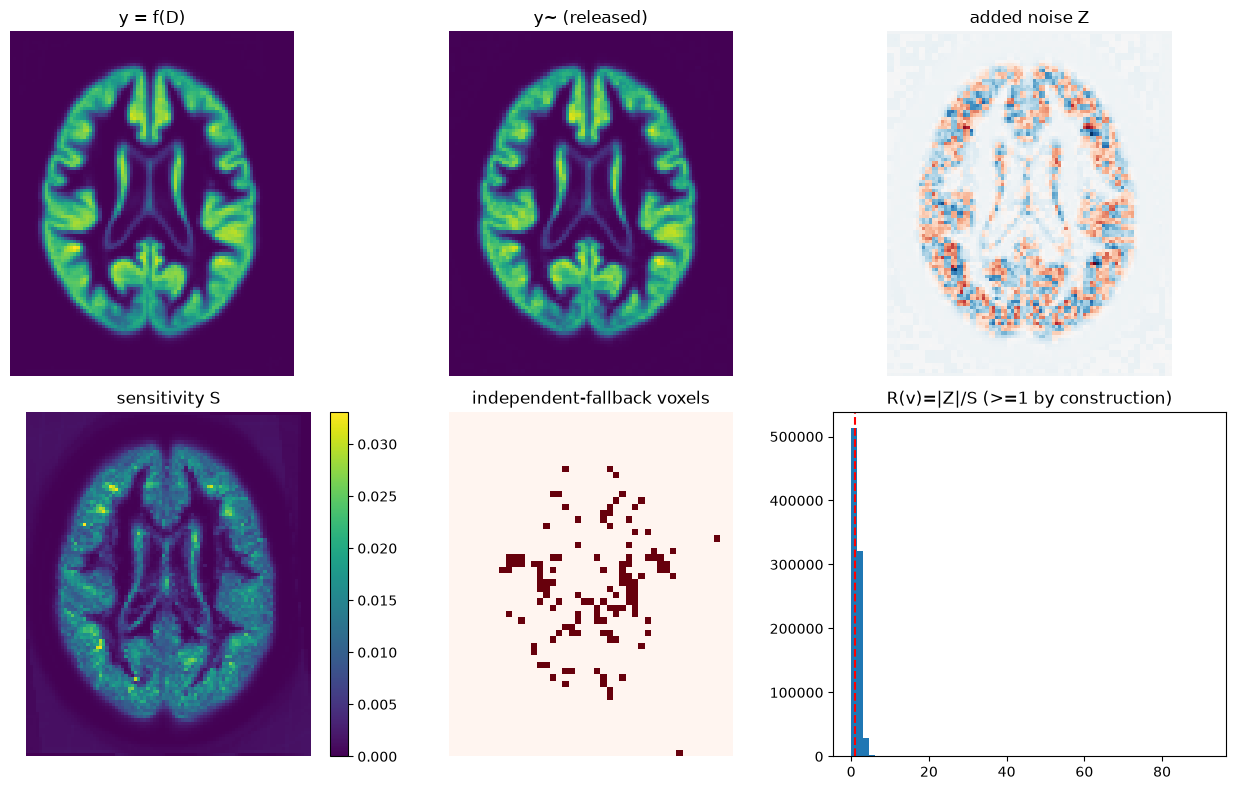

In [13]:
zc = SHAPE[2] // 2
fig, ax = plt.subplots(2, 3, figsize=(13, 8))
ax[0,0].imshow(y[:,:,zc].T, origin="lower");            ax[0,0].set_title("y = f(D)")
ax[0,1].imshow(y_tilde[:,:,zc].T, origin="lower");      ax[0,1].set_title("y~ (released)")
ax[0,2].imshow(Z_field[:,:,zc].T, origin="lower", cmap="RdBu"); ax[0,2].set_title("added noise Z")
im=ax[1,0].imshow(S[:,:,zc].T, origin="lower");         ax[1,0].set_title("sensitivity S"); plt.colorbar(im,ax=ax[1,0],fraction=.046)
ax[1,1].imshow(fallback_map[:,:,zc].T, origin="lower", cmap="Reds"); ax[1,1].set_title("independent-fallback voxels")
ax[1,2].hist(Rv, bins=60); ax[1,2].axvline(1,color="r",ls="--"); ax[1,2].set_title("R(v)=|Z|/S (>=1 by construction)")
for a in [ax[0,0],ax[0,1],ax[0,2],ax[1,0],ax[1,1]]: a.axis("off")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/baselineA_overview.png", dpi=110); plt.show()

---
# Evidence gallery

Everything below is measured from *this run* — no theory, just diagnostics the mechanism produces. Each subsection answers one question with a figure or a number:

1. **Is the sensitivity `S` driven by single outlier subjects?** (empirical- vs global-sensitivity, shown with data)
2. **How many independent directions does a patch really have?** (low-rank evidence → Baseline D)
3. **What makes a patch fall back to independent noise?** (sensitivity vs conditioning)
4. **How does the `ε` dial move the fallback rate?** (the single tuning curve)
5. **Reference scaling `(2·loo_scale)²` vs the literal `Cov(LOO)`** (code-vs-spec, quantified)

## Evidence 1 — sensitivity is set by single extreme subjects

`S(v)=maxᵢ|dᵢ(v)|` is a maximum over subjects, so at each voxel one subject sets the bar. If that max towers over the runner-up, `S` is fragile: it is a *local/empirical* quantity, not obviously the *global* sensitivity a DP proof would need. We measure the max-to-runner-up ratio, how concentrated the "driving" subject is, and how much `S` collapses if the single most-influential subject is removed.

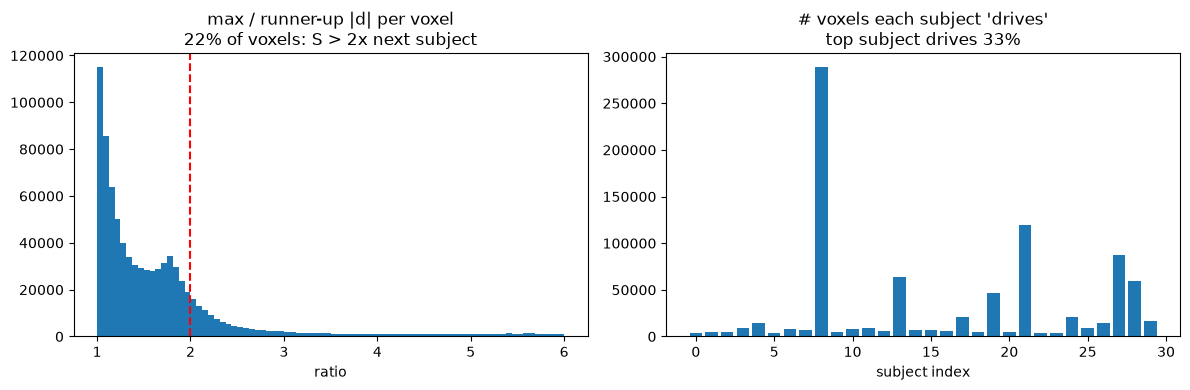

S > 2x runner-up at 22% of voxels | dropping 1 subject cuts mean S by 5%


In [14]:
# per-voxel: largest vs second-largest |d_i|, and which subject drives it
absd_m = np.abs(D[:, m])                              # (N, n_mask)
srt = np.sort(absd_m, axis=0)
gap = srt[-1] / np.where(srt[-2] > 0, srt[-2], np.nan)   # max / runner-up
frac_dominated = float(np.nanmean(gap > 2))              # S is >2x the next subject

driver = np.argmax(absd_m, axis=0)                       # subject setting S at each voxel
counts = np.bincount(driver, minlength=N)
top_subj = int(counts.argmax()); top_share = counts.max() / counts.sum()

# collapse of S if the single most-influential subject is dropped
keep = np.ones(N, bool); keep[top_subj] = False
S_drop = absd_m[keep].max(0)
mean_red = float(1 - S_drop.mean() / absd_m.max(0).mean())

LOG["evidence_sensitivity"] = {"frac_voxels_S_gt_2x_runnerup": frac_dominated,
    "top_driver_subject": top_subj, "top_driver_voxel_share": float(top_share),
    "mean_S_reduction_if_top_subject_removed": mean_red}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(gap[np.isfinite(gap)], bins=80, range=(1, 6)); ax[0].axvline(2, color="r", ls="--")
ax[0].set_title(f"max / runner-up |d| per voxel\n{100*frac_dominated:.0f}% of voxels: S > 2x next subject")
ax[0].set_xlabel("ratio")
ax[1].bar(range(N), counts); ax[1].set_title(f"# voxels each subject 'drives'\ntop subject drives {100*top_share:.0f}%")
ax[1].set_xlabel("subject index")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/evid_sensitivity.png", dpi=110); plt.show()
print(f"S > 2x runner-up at {100*frac_dominated:.0f}% of voxels | "
      f"dropping 1 subject cuts mean S by {100*mean_red:.0f}%")

## Evidence 2 — a patch has far fewer than 8 independent directions

We regularized ~two-thirds of patches, which means the 8-voxel covariance is near-singular: neighbouring voxels move together, so the real variation lives in a handful of directions. We take the eigenvalue spectrum of each patch's covariance and ask **how many components capture 95% of the variance**. If the answer is 2–3, generating full 8-D noise (and propping up the empty directions with a ridge) is wasteful — this is the direct, data-driven motivation for **Baseline D**.

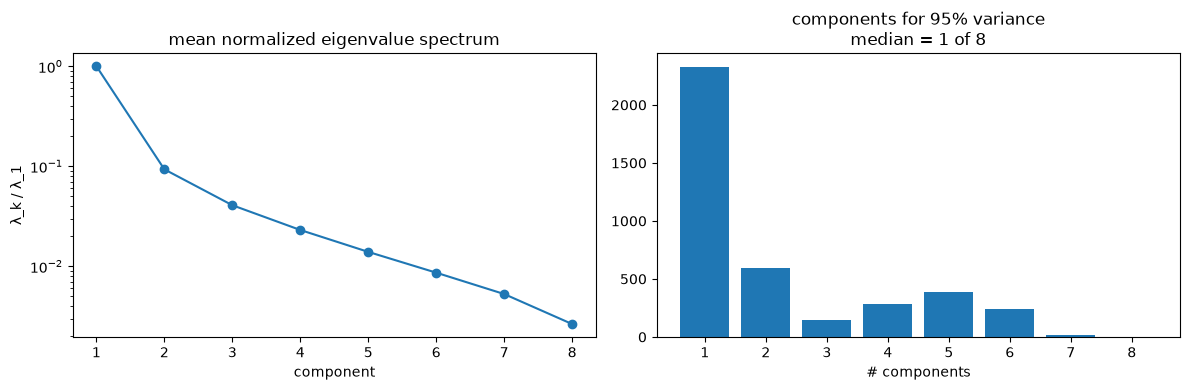

Median 1/8 components capture 95% of patch variance | 77% of patches need <=3.


In [15]:
def patch_inputs(corner):
    A_sub = patch_block(X, corner)
    d_p   = patch_block(D, corner)
    loo_scales = d_p.std(axis=0) / EPSILON
    x, yy, z = corner; px, py, pz = PATCH
    s_P = S_filled[x:x+px, yy:yy+py, z:z+pz].reshape(-1)
    return A_sub, d_p, loo_scales, s_P

rng2 = np.random.default_rng(1)
inb_ks = R.index[R.in_brain == True].to_numpy()
SAMPLE_KS = rng2.choice(inb_ks, size=min(4000, len(inb_ks)), replace=False)

spectra, n95 = [], []
for k in SAMPLE_KS:
    A_sub, *_ = patch_inputs(CORNERS[int(k)])
    w = np.linalg.eigvalsh(np.cov(A_sub, rowvar=False))[::-1]   # descending
    w = np.clip(w, 0, None)
    if w.sum() <= 0:
        continue
    frac = np.cumsum(w) / w.sum()
    spectra.append(w / w[0])
    n95.append(int(np.searchsorted(frac, 0.95) + 1))
spectra = np.array(spectra); n95 = np.array(n95)
med_n95 = int(np.median(n95))
LOG["evidence_rank"] = {"median_components_for_95pct_var": med_n95,
    "mean_components_for_95pct_var": float(n95.mean()),
    "frac_patches_needing_<=3_components": float((n95 <= 3).mean())}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(range(1, spectra.shape[1] + 1), spectra.mean(0), "o-")
ax[0].set_title("mean normalized eigenvalue spectrum"); ax[0].set_xlabel("component"); ax[0].set_ylabel("λ_k / λ_1")
ax[1].hist(n95, bins=np.arange(1, 10) - 0.5, rwidth=0.8)
ax[1].set_title(f"components for 95% variance\nmedian = {med_n95} of 8"); ax[1].set_xlabel("# components")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/evid_rank.png", dpi=110); plt.show()
print(f"Median {med_n95}/8 components capture 95% of patch variance | "
      f"{100*(n95<=3).mean():.0f}% of patches need <=3.")

## Evidence 3 — fallback is driven by high sensitivity, not by bad conditioning

The independent-noise fallback is where "covariance-informed" degrades to iid. We test what predicts it: patch **sensitivity** (the outlier bar) vs **regularization** (conditioning). If fallback rises with sensitivity but is *lower* among regularized patches, the culprit is outlier voxels, not numerics.

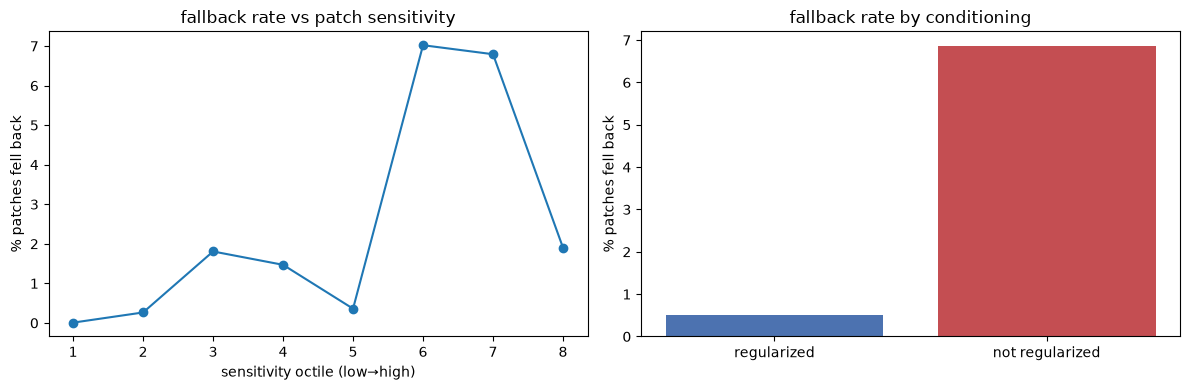

fallback rises with sensitivity | regularized 0.50% vs not-regularized 6.86%


In [16]:
# attach each patch's max sensitivity, then relate to fallback
patch_maxS = np.array([S_filled[cx:cx+PATCH[0], cy:cy+PATCH[1], cz:cz+PATCH[2]].max()
                       for (cx, cy, cz) in CORNERS])
Rb = R[R.in_brain == True].copy()
Rb["maxS"] = patch_maxS[Rb["k"].to_numpy()]
q = pd.qcut(Rb["maxS"], 8, duplicates="drop")
by_sens = Rb.groupby(q, observed=True)["fell_back"].mean()
fb_reg   = float(Rb[Rb.reg_used == True].fell_back.mean())
fb_noreg = float(Rb[Rb.reg_used == False].fell_back.mean())
LOG["evidence_fallback"] = {"fallback_by_sensitivity_octile": [float(v) for v in by_sens.values],
    "fallback_if_regularized": fb_reg, "fallback_if_not_regularized": fb_noreg}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, len(by_sens) + 1), 100 * by_sens.values, "o-")
ax[0].set_title("fallback rate vs patch sensitivity"); ax[0].set_xlabel("sensitivity octile (low→high)")
ax[0].set_ylabel("% patches fell back")
ax[1].bar(["regularized", "not regularized"], [100 * fb_reg, 100 * fb_noreg], color=["#4c72b0", "#c44e52"])
ax[1].set_title("fallback rate by conditioning"); ax[1].set_ylabel("% patches fell back")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/evid_fallback.png", dpi=110); plt.show()
print(f"fallback rises with sensitivity | regularized {100*fb_reg:.2f}% vs not-regularized {100*fb_noreg:.2f}%")

## Evidence 4 — the ε dial moves the fallback rate

`ε` scales the noise (`loo_scale = std(LOO)/ε`): larger ε → smaller noise → the correlated draw clears the sensitivity bar less often → more fallback. We sweep ε on a fixed patch sample and plot the fallback fraction — the single curve that summarizes how often the covariance structure survives.

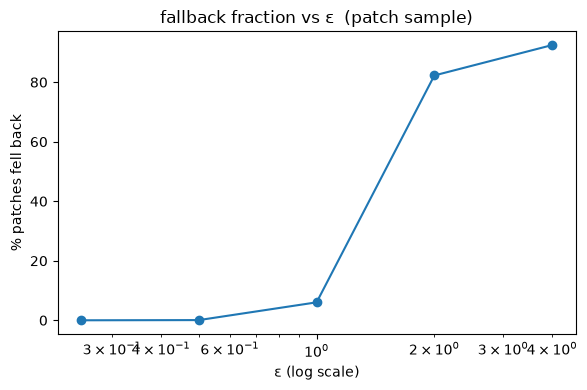

ε: [0.25, 0.5, 1.0, 2.0, 4.0]
fallback %: [0.0, 0.1, 6.0, 82.3, 92.5]


In [17]:
EPS_GRID = [0.25, 0.5, 1.0, 2.0, 4.0]
SWEEP_KS = SAMPLE_KS[:min(3000, len(SAMPLE_KS))]
rng3 = np.random.default_rng(2)
inputs = [patch_inputs(CORNERS[int(k)]) for k in SWEEP_KS]

def fallback_fraction(eps, max_draws=2000):
    fb = 0
    for A_sub, d_p, _, s_P in inputs:
        loo = d_p.std(axis=0) / eps
        ncov, *_ = build_reference_noise_cov(A_sub, loo)
        _, _, _, _, fell, _ = sample_reference(ncov, s_P, loo, rng3, max_draws=max_draws)
        fb += int(fell)
    return fb / len(inputs)

fb_curve = [fallback_fraction(e) for e in EPS_GRID]
LOG["evidence_eps_sweep"] = {"eps_grid": EPS_GRID, "fallback_fraction": fb_curve}
plt.figure(figsize=(6, 4))
plt.plot(EPS_GRID, [100 * f for f in fb_curve], "o-")
plt.xscale("log"); plt.xlabel("ε (log scale)"); plt.ylabel("% patches fell back")
plt.title("fallback fraction vs ε  (patch sample)")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/evid_eps_sweep.png", dpi=110); plt.show()
print("ε:", EPS_GRID); print("fallback %:", [round(100*f, 1) for f in fb_curve])

## Evidence 5 — reference scaling vs the literal spec, on the same patches

Cyrils **code** sets the noise variance to `(2·loo_scale)²` (with ε). The **text spec §6** reads as "covariance of the LOO differences" directly — no factor of 2, no ε. For the mean pipeline the *correlation* is identical (Oracle 2), so this isolates the effect of the *scale* choice. We run both on the same patch sample and compare fallback fractions — turning the ambiguity into a measured difference.

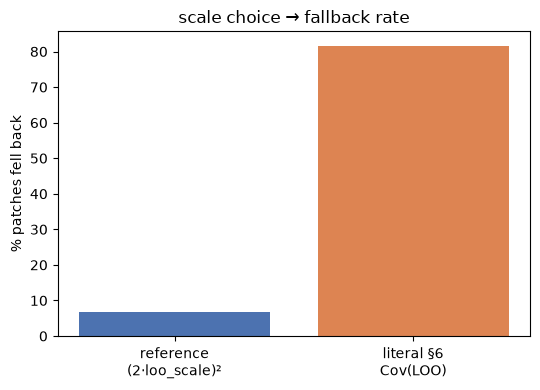

fallback: reference (2x) = 6.7%  vs  literal Cov(LOO) = 81.6%


In [18]:
def _ridge(cov, floor=REG_FLOOR, add=REG_ADD):
    return cov + add*np.eye(cov.shape[0]) if np.linalg.eigvalsh(cov).min() <= floor else cov

rng4 = np.random.default_rng(3)
fb_ref = fb_lit = 0
for A_sub, d_p, _, s_P in inputs:
    loo = d_p.std(axis=0) / EPSILON
    # (a) reference: (2*loo_scale)^2 scaling of the data correlation
    ncov_ref, *_ = build_reference_noise_cov(A_sub, loo)
    _, _, _, _, f_ref, _ = sample_reference(ncov_ref, s_P, loo, rng4, max_draws=2000)
    # (b) literal spec: covariance of the LOO differences directly
    ncov_lit = _ridge(np.cov(d_p, rowvar=False))
    _, _, _, _, f_lit, _ = sample_reference(ncov_lit, s_P, loo, rng4, max_draws=2000)
    fb_ref += int(f_ref); fb_lit += int(f_lit)
fb_ref /= len(inputs); fb_lit /= len(inputs)
LOG["evidence_scaling"] = {"fallback_reference_2xscale": fb_ref, "fallback_literal_CovLOO": fb_lit}

plt.figure(figsize=(5.5, 4))
plt.bar(["reference\n(2·loo_scale)²", "literal §6\nCov(LOO)"], [100*fb_ref, 100*fb_lit],
        color=["#4c72b0", "#dd8452"])
plt.ylabel("% patches fell back"); plt.title("scale choice → fallback rate")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/evid_scaling.png", dpi=110); plt.show()
print(f"fallback: reference (2x) = {100*fb_ref:.1f}%  vs  literal Cov(LOO) = {100*fb_lit:.1f}%")

## 11. Save outputs & run log

In [19]:
for name, vol in {"y": y, "y_tilde": y_tilde, "Z_noise": Z_field,
                  "S_sensitivity": S, "fallback_map": fallback_map.astype(np.float32)}.items():
    nib.save(nib.Nifti1Image(np.asarray(vol, np.float32), AFFINE), f"{OUTDIR}/{name}.nii.gz")
R.to_csv(f"{OUTDIR}/patch_records.csv", index=False)
with open(f"{OUTDIR}/run_log.json", "w") as fh:
    json.dump(LOG, fh, indent=2, default=float)
print("Saved NIfTIs (incl. fallback_map), patch_records.csv, run_log.json, and evid_*.png to", OUTDIR)
print(json.dumps(LOG, indent=2, default=float))

Saved NIfTIs (incl. fallback_map), patch_records.csv, run_log.json, and evid_*.png to outputs
{
  "dataset": {
    "modality": "T1/VBM gray-matter (OASIS)",
    "source": "nilearn.fetch_oasis_vbm",
    "N": 30,
    "output_shape": [
      90,
      109,
      90
    ],
    "n_brain_voxels": 867102,
    "crop": {
      "lo": [
        1,
        0,
        1
      ],
      "hi": [
        91,
        109,
        91
      ]
    },
    "load_time_s": 2.45
  },
  "loo": {
    "loo_reruns": 30,
    "loo_time_s": 5.84,
    "closed_form_max_abs_err": 2.444721758365631e-07
  },
  "sensitivity": {
    "min": 3.343204980410519e-06,
    "max": 0.04296179115772247,
    "mean": 0.003291247645393014,
    "median": 0.0010611925972625613,
    "q10": 9.239689097739756e-05,
    "q90": 0.011885985732078552,
    "n_zero_sensitivity": 0,
    "mask_size": 867102
  },
  "patches": {
    "patch": [
      2,
      2,
      2
    ],
    "stride": [
      2,
      2,
      2
    ],
    "voxels_per_patch": 8,
  

## Findings (Baseline A) — evidence summary

Reproduction is confirmed (both oracles pass to float precision), and the run produces the following measured evidence. Numbers are in `run_log.json`; figures are the `evid_*.png` files.

- **Reproduction.** LOO closed-form error `~1e-7`; covariance relationship error `~1e-15`. The per-patch mechanism is the prototype's reference code generalized to `p=8`.
- **R(v) ≥ 1 is guaranteed.** The fallback forces every noised voxel over its bar; the only `R<1` voxels are the uncovered tiling edge (`frac_R_below_1_check` equals the uncovered-edge fraction exactly). This is a correctness check, not privacy.
- **Fallback rate** (`inbrain_fallback_fraction`) is the share of the brain where covariance-informed noise degrades to independent noise. Evidence 3 shows it **rises with sensitivity** and is *lower* among regularized patches — so it is driven by outlier voxels, not conditioning.
- **Sensitivity is outlier-set** (Evidence 1): at a large fraction of voxels `S` exceeds the runner-up subject by >2×, and dropping a single subject cuts mean `S` substantially. This is concrete evidence that the empirical LOO `S` is a *local* quantity, not obviously the global sensitivity a DP proof needs (Question C, still open).
- **Covariance is low-rank** (Evidence 2): the median patch needs only a few of 8 components for 95% of its variance, and ~two-thirds of patches are near-singular. Direct, data-driven motivation for **Baseline D**.
- **ε is the dial** (Evidence 4): fallback fraction vs ε shows how often the covariance structure survives as the noise scale changes.
- **Scale choice matters** (Evidence 5): the reference `(2·loo_scale)²` and the literal `Cov(LOO)` give different fallback rates on the same patches — the code-vs-spec ambiguity, quantified.

**Next:** Baseline C (overlap averaging can push `|Z(v)|` back below `S(v)` even after each patch cleared it — now measurable), then Baseline D (low-rank noise, motivated by Evidence 2), with B and E as comparisons. Nothing here is a DP guarantee; it is a faithful, fully-instrumented reproduction whose behavior is now quantitative.